In [74]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.feature_selection import f_regression

In [75]:
df = pd.read_csv("player_style_stats.csv")
df

,Randomness,Aggression sensitivity,Rounds played,Amount won relative to big blind,Win per round
0,0.230575,1.506533,0,0.00,0.000000
1,0.310145,0.917839,3,-1.00,-0.333333
2,0.365693,1.923485,5,-1.50,-0.300000
3,0.929555,1.911061,7,-2.00,-0.285714
4,0.085924,0.602008,7,-20.50,-2.928571
...,...,...,...,...,...
3325,0.827643,1.657246,167,-0.50,-0.002994
3326,0.882058,0.068541,169,-3.50,-0.020710
3327,0.183351,1.975042,170,-1.00,-0.005882
3328,0.880374,1.172557,171,2.25,0.013158


In [76]:
# Remove outliers (win per round more than X standard deviations from the mean)
df = df[np.abs(df['Win per round'] - df['Win per round'].mean()) <= (3 * df['Win per round'].std())]
df

,Randomness,Aggression sensitivity,Rounds played,Amount won relative to big blind,Win per round
0,0.230575,1.506533,0,0.00,0.000000
1,0.310145,0.917839,3,-1.00,-0.333333
2,0.365693,1.923485,5,-1.50,-0.300000
3,0.929555,1.911061,7,-2.00,-0.285714
4,0.085924,0.602008,7,-20.50,-2.928571
...,...,...,...,...,...
3325,0.827643,1.657246,167,-0.50,-0.002994
3326,0.882058,0.068541,169,-3.50,-0.020710
3327,0.183351,1.975042,170,-1.00,-0.005882
3328,0.880374,1.172557,171,2.25,0.013158


In [77]:
df.dtypes

Randomness                          float64
Aggression sensitivity              float64
Rounds played                         int64
Amount won relative to big blind    float64
Win per round                       float64
dtype: object

In [78]:
X = df[["Randomness", "Aggression sensitivity"]]
y = df["Win per round"]

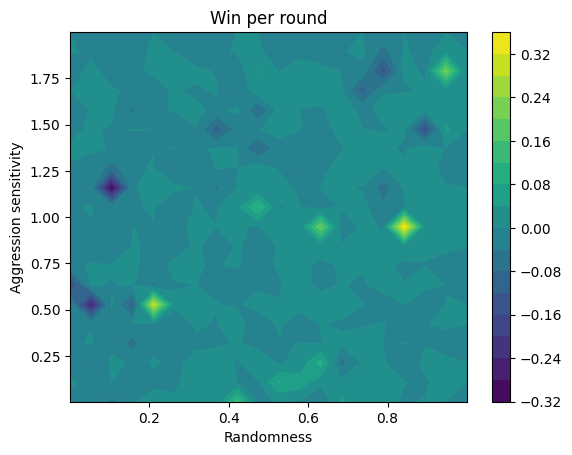

In [79]:
# Plot heatmap of randomness and aggression sensitivity vs win per round
# Create grid with buckets of randomness and aggression sensitivity values:
buckets = 20
r_min = df["Randomness"].min()
r_max = df["Randomness"].max()
a_min = df["Aggression sensitivity"].min()
a_max = df["Aggression sensitivity"].max()
randomness = np.linspace(r_min, r_max, buckets)
aggression_sensitivity = np.linspace(a_min, a_max, buckets)
R, A = np.meshgrid(randomness, aggression_sensitivity)

# For each bucket, get the empirical mean
Z = np.zeros_like(R)
for ri, from_r in enumerate(randomness[:-1]):
    to_r = randomness[ri + 1] if ri + 1 < len(randomness) else r_max
    r_mask = (df["Randomness"] >= from_r) & (df["Randomness"] < to_r)
    for ai, from_a in enumerate(aggression_sensitivity[:-1]):
        to_a = aggression_sensitivity[ai + 1] if ai + 1 < len(aggression_sensitivity) else a_max
        a_mask = (df["Aggression sensitivity"] >= from_a) & (df["Aggression sensitivity"] < to_a)
        mask = r_mask & a_mask
        Z[ai, ri] = df[mask]["Win per round"].mean()

plt.figure()
plt.contourf(R, A, Z, levels=20)
plt.colorbar()
plt.xlabel("Randomness")
plt.ylabel("Aggression sensitivity")
plt.title("Win per round")
plt.show()

Coef: [0.02514586]
P-value: 0.00268412233573323


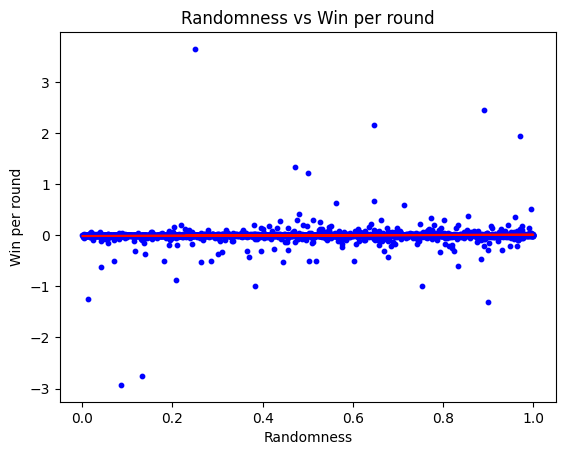

In [80]:
# Plot randomness vs win per round
plt.scatter(df["Randomness"], df["Win per round"], c="blue", s=10)
model = LinearRegression().fit(X[["Randomness"]], y)
print("Coef:", model.coef_)
print("P-value:", model.score(X[["Randomness"]], y))
plt.plot(df["Randomness"], model.predict(X[["Randomness"]]), color="red")
plt.xlabel("Randomness")
plt.ylabel("Win per round")
plt.title("Randomness vs Win per round")
plt.show()

Coef: [-0.00403678]
P-value: 0.00028396866150104394


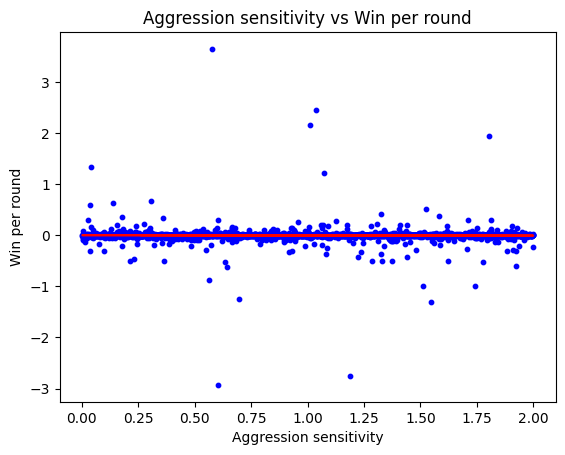

In [81]:
# Plot aggression sensitivity vs win per round
plt.scatter(df["Aggression sensitivity"], df["Win per round"], c="blue", s=10)
model = LinearRegression().fit(X[["Aggression sensitivity"]], y)
print("Coef:", model.coef_)
print("P-value:", model.score(X[["Aggression sensitivity"]], y))
plt.plot(df["Aggression sensitivity"], model.predict(X[["Aggression sensitivity"]]), color="red")
plt.xlabel("Aggression sensitivity")
plt.ylabel("Win per round")
plt.title("Aggression sensitivity vs Win per round")
plt.show()

In [82]:
# Add combinations of features to capture non-linear relationships
def preprocess(X_df):
    X_df["Randomness squared"] = X_df.loc[:, "Randomness"] ** 2
    X_df["Aggression sensitivity squared"] = X_df.loc[:, "Aggression sensitivity"] ** 2
    X_df["Randomness * Aggression sensitivity"] = X_df.loc[:, "Randomness"] * X_df.loc[:, "Aggression sensitivity"]

preprocess(X)

/var/folders/4_/zn5f20ls53v5r1bw3w8dbh0h0000gn/T/ipykernel_6690/3384249107.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_df["Randomness squared"] = X_df.loc[:, "Randomness"] ** 2
/var/folders/4_/zn5f20ls53v5r1bw3w8dbh0h0000gn/T/ipykernel_6690/3384249107.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_df["Randomness * Aggression sensitivity"] = X_df.loc[:, "Randomness"] * X_df.loc[:, "Aggression sensitivity"]


In [83]:
model = LinearRegression()
model.fit(X, y)
coef_df = pd.DataFrame(model.coef_, index=X.columns, columns=["Coefficient"])

In [84]:
# Calculate p-value for each coefficient
f_values, p_values = f_regression(X, y)
coef_df["P-value"] = p_values
coef_df

,Coefficient,P-value
Randomness,0.066362,0.002847
Aggression sensitivity,-0.001792,0.332077
Randomness squared,-0.037111,0.009274
Randomness * Aggression sensitivity,-0.004288,0.218484


Optimal parameters:
 Randomness                0.89899
Aggression sensitivity    0.00000
Name: 89, dtype: float64


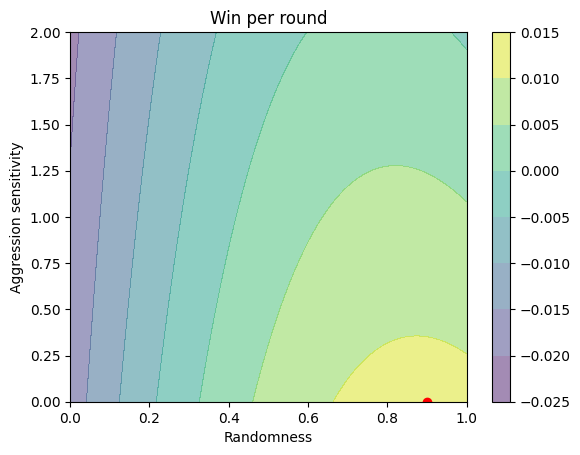

In [85]:
# Contour plot to find the best player style
randomness = np.linspace(0, 1, 100)
aggression = np.linspace(0, 2, 100)
X1, X2 = np.meshgrid(randomness, aggression)
plt_X = np.c_[X1.ravel(), X2.ravel()]
plt_X_df = pd.DataFrame(plt_X, columns=["Randomness", "Aggression sensitivity"])
preprocess(plt_X_df)
plt_y = model.predict(plt_X_df)
plt_y = plt_y.reshape(X1.shape)

# Calculate optimal player style
optimal_player_style = plt_X_df.loc[np.argmax(plt_y)]
print("Optimal parameters:\n", optimal_player_style[["Randomness", "Aggression sensitivity"]])

plt.contourf(X1, X2, plt_y, alpha=0.5)
plt.colorbar()
plt.xlabel("Randomness")
plt.ylabel("Aggression sensitivity")
plt.title("Win per round")
plt.scatter(optimal_player_style["Randomness"], optimal_player_style["Aggression sensitivity"], c="red")
plt.show()